In [6]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df=pd.read_csv('iris.csv')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df=df.drop(columns=['petal_length','petal_width'])

In [5]:
df.head()

,sepal_length,sepal_width,species
0,5.1,3.5,setosa
1,4.9,3.0,setosa
2,4.7,3.2,setosa
3,4.6,3.1,setosa
4,5.0,3.6,setosa


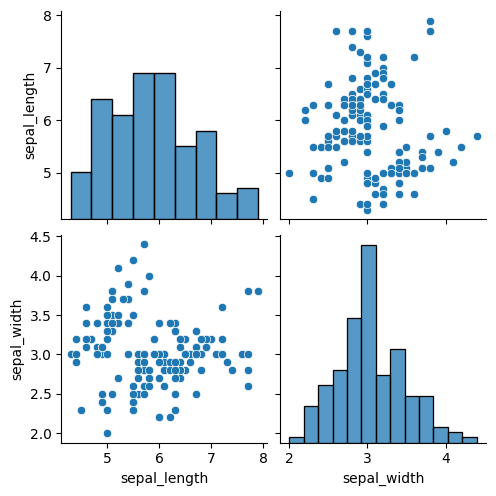

In [10]:
sns.pairplot(df)

In [8]:
df.shape

(150, 3)

In [11]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [17]:
X.head()

,sepal_length,sepal_width
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [16]:
y.head()

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [19]:
clf1 = LogisticRegression()
clf2 = RandomForestClassifier()
clf3 = KNeighborsClassifier()

In [20]:
estimators = [('lr',clf1),('rf',clf2),('knn',clf3)]

In [46]:
for estimator in estimators:
    x = cross_val_score(estimator[1],X,y,cv=10,scoring='accuracy')
    print(estimator[0],np.round(np.mean(x),2))

lr 0.81
rf 0.71
knn 0.76


## hard voting

In [47]:
from sklearn.ensemble import VotingClassifier
vc=VotingClassifier(estimators,voting='hard')
x = cross_val_score(vc,X,y,cv=5,scoring='accuracy')
print(np.round(np.mean(x),2))

0.79


## soft voting

In [48]:
vc=VotingClassifier(estimators,voting='soft')
x = cross_val_score(vc,X,y,cv=5,scoring='accuracy')
print(np.round(np.mean(x),2))

0.78


## using weights

In [50]:
for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            vc=VotingClassifier(estimators=estimators,voting='hard',weights=[i,j,k])
            x=cross_val_score(vc,X,y,cv=10,scoring='accuracy')
            print([i,j,k],np.round(np.mean(x),3))

[1, 1, 1] 0.773
[1, 1, 2] 0.76
[1, 1, 3] 0.76
[1, 2, 1] 0.753
[1, 2, 2] 0.773
[1, 2, 3] 0.76
[1, 3, 1] 0.727
[1, 3, 2] 0.733
[1, 3, 3] 0.767
[2, 1, 1] 0.787
[2, 1, 2] 0.773
[2, 1, 3] 0.76
[2, 2, 1] 0.773
[2, 2, 2] 0.773
[2, 2, 3] 0.773
[2, 3, 1] 0.753
[2, 3, 2] 0.773
[2, 3, 3] 0.767
[3, 1, 1] 0.807
[3, 1, 2] 0.787
[3, 1, 3] 0.767
[3, 2, 1] 0.787
[3, 2, 2] 0.767
[3, 2, 3] 0.773
[3, 3, 1] 0.773
[3, 3, 2] 0.773
[3, 3, 3] 0.773
